In [4]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

pd.set_option('display.float_format', lambda x: '%.2f' % x)
pd.set_option('display.max_rows', 1000)

#Import finale Daten

In [5]:
# products_cl.csv
url = "https://drive.google.com/file/d/1aZ5DcFIOzRJklm9HqUm_zL1KMJFnGHky/view?usp=sharing"
path = "https://drive.google.com/uc?export=download&id="+url.split("/")[-2]
sales_qu = pd.read_csv(path)

In [6]:
sales_df = sales_qu.copy()

# **Daten Visualisirung**

In [7]:
sales_df['created_date'] =pd.to_datetime(sales_df['created_date'], errors='coerce')
sales_df['date'] =pd.to_datetime(sales_df['date'], errors='coerce')

In [8]:
sales_df["discount_status"] = sales_df["discount_percent"].apply(
    lambda x: "Discounted" if x > 0 else "No Discount"
)

##Frage 1 – Rabattstatus

In [9]:
# ----------------------------------------------------------
# Frage 1
# Vergleich des durchschnittlichen Umsatzes von Produkten
# mit und ohne Rabatt.
# ----------------------------------------------------------
sales_df.groupby("discount_status")["umsatz"].mean().round(2)

,umsatz
discount_status,
Discounted,257.75
No Discount,181.69


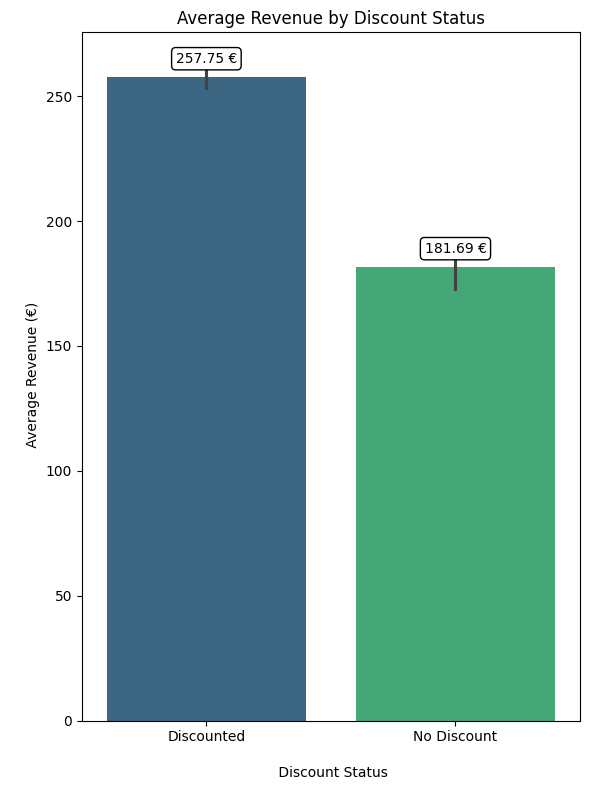

In [10]:
# Visualisierung des durchschnittlichen Umsatzes nach Rabattstatus.
plt.figure(figsize=(6,8))

ax = sns.barplot(
    data=sales_df,
    x="discount_status",
    y="umsatz",
    hue='discount_status',
    palette="viridis"
)

plt.title("Average Revenue by Discount Status")
plt.xlabel("\n Discount Status")
plt.ylabel("\n Average Revenue (€)")
plt.tight_layout()
for container in ax.containers:
    ax.bar_label(
        container,
        fmt="%.2f €",
        padding=8,
        bbox=dict(
            facecolor="white",
            edgecolor="black",
            boxstyle="round,pad=0.3"
        )
    )
plt.savefig('charts_01.png', dpi=300, bbox_inches='tight')
plt.show()

# Erkenntnis:
# Das Diagramm zeigt den durchschnittlichen Umsatz
# von rabattierten und nicht rabattierten Produkten.

In [11]:
from google.colab import files
files.download('charts_01.png')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

##Frage 2 – Saison (Rabattierte Produkte)

In [12]:
# ----------------------------------------------------------
# Frage 2
# Vergleich des durchschnittlichen Umsatzes rabattierter
# Produkte zwischen Normal Season und Peak Season.
# ----------------------------------------------------------
sales_df["month"] = sales_df["date"].dt.to_period("M").astype(str)

In [13]:
sales_df["month"] = sales_df["date"].dt.strftime("%Y-%m")

In [14]:
sales_count_month = (
    sales_df
    .groupby("month")
    .size()
    .reset_index(name="sales_count")
)

sales_count_month

,month,sales_count
0,2017-01,6636
1,2017-02,2875
2,2017-03,275
3,2017-04,2089
4,2017-05,2445
5,2017-06,2040
6,2017-07,4508
7,2017-08,3008
8,2017-09,2862
9,2017-10,4039


In [15]:
peak_months = ["2017-11", "2017-12", "2018-01"]

sales_df["season"] = sales_df["month"].apply(
    lambda x: "Peak Season" if x in peak_months else "Normal Season"
)

In [16]:
discounted_df = sales_df[
    sales_df["discount_status"] == "Discounted"
]

In [17]:
discounted_df.groupby("season")["umsatz"].mean().round(2)

,umsatz
season,
Normal Season,237.54
Peak Season,288.10


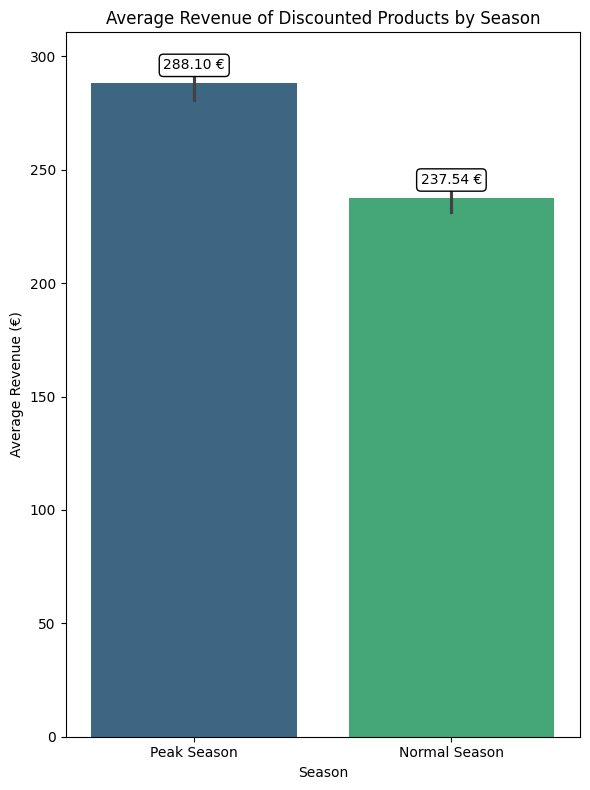

In [18]:
plt.figure(figsize=(6,8))

ax = sns.barplot(
    data=discounted_df,
    x="season",
    y="umsatz",
    hue="season",
    legend=False,
    palette="viridis"
)

for container in ax.containers:
    ax.bar_label(
        container,
        fmt="%.2f €",
        padding=8,
        bbox=dict(
            facecolor="white",
            edgecolor="black",
            boxstyle="round,pad=0.3"
        )
    )

plt.title("Average Revenue of Discounted Products by Season")
plt.xlabel("Season")
plt.ylabel("Average Revenue (€)")

plt.tight_layout()
plt.savefig('charts_02_02.png', dpi=300, bbox_inches='tight')

plt.show()
# Erkenntnis:
# Während der Peak Season erzielen rabattierte Produkte
# einen höheren durchschnittlichen Umsatz.

In [19]:
files.download('charts_02_02.png')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

##Frage 3 – Verkaufsmenge nach Saison

In [20]:
# ----------------------------------------------------------
# Frage 3
# Vergleich der durchschnittlichen Verkaufsmenge
# zwischen den beiden Saisons.
# ----------------------------------------------------------
sales_per_month = (
    discounted_df
    .groupby("month")
    .size()
    .reset_index(name="sales")
)

sales_per_month

,month,sales
0,2017-01,6055
1,2017-02,2603
2,2017-03,230
3,2017-04,1882
4,2017-05,2124
5,2017-06,1787
6,2017-07,4194
7,2017-08,2784
8,2017-09,2598
9,2017-10,3770


In [21]:
sales_per_month["season"] = sales_per_month["month"].apply(
    lambda x: "Peak Season" if x in peak_months else "Normal Season"
)

In [22]:
sales_per_month.groupby("season")["sales"].mean().round(2)

,sales
season,
Normal Season,2802.08
Peak Season,7462.67


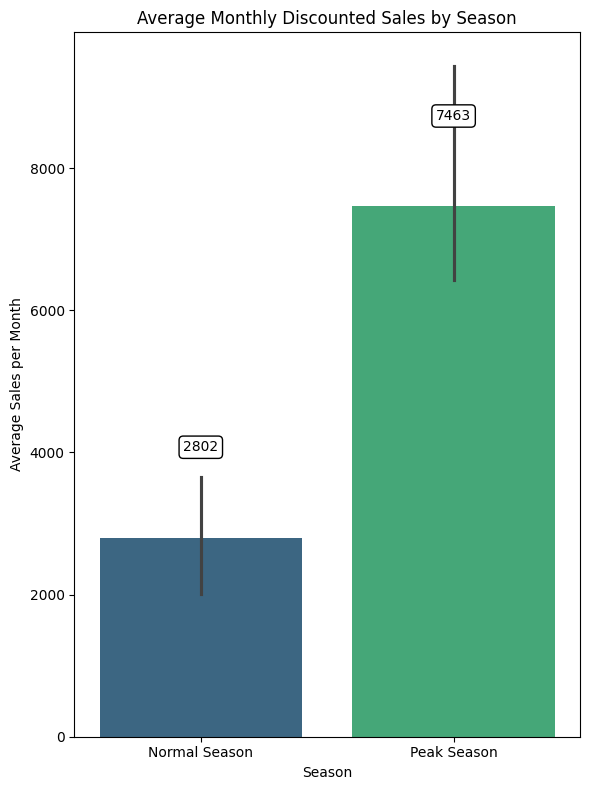

In [23]:
plt.figure(figsize=(6,8))

ax = sns.barplot(
    data=sales_per_month,
    x="season",
    y="sales",
    hue="season",
    legend=False,
    palette="viridis"
)

for container in ax.containers:
    ax.bar_label(
        container,
        fmt="%.0f",
        padding=60,
        bbox=dict(
            facecolor="white",
            edgecolor="black",
            boxstyle="round,pad=0.3"
        )
    )

plt.title("Average Monthly Discounted Sales by Season")
plt.xlabel("Season")
plt.ylabel("Average Sales per Month")
plt.savefig('charts_02_01.png', dpi=300, bbox_inches='tight')
plt.tight_layout()
plt.show()
# Erkenntnis:
# In der Peak Season werden durchschnittlich
# mehr Produkte verkauft.

In [24]:
files.download('charts_02_01.png')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

##Frage 4 – Durchschnittlicher Umsatz nach Rabattstufe (Normal Season)

In [25]:
# ----------------------------------------------------------
# Frage 4
# Durchschnittlicher Umsatz nach Rabattkategorie
# in der Normal Season.
# ----------------------------------------------------------
normal_df = sales_df[sales_df["season"] == "Normal Season"]

In [26]:
normal_discount = (
    normal_df
    .groupby("rabatt_bucket")["umsatz"]
    .mean()
    .round(2)
    .reset_index()
)

normal_discount

,rabatt_bucket,umsatz
0,"(0, 10]",488.78
1,"(10, 20]",225.89
2,"(20, 30]",170.26
3,"(30, 40]",108.15
4,"(40, 50]",42.15
5,"(50, 60]",38.43
6,"(60, 70]",27.35
7,"(70, 80]",36.91
8,"(80, 90]",27.24
9,"(90, 100]",240.40


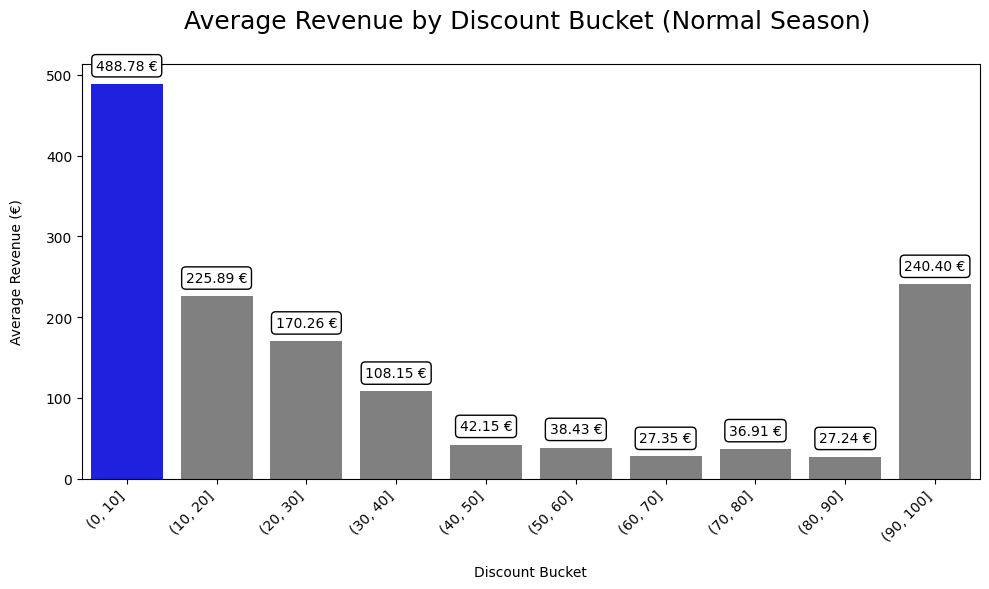

In [27]:
plt.figure(figsize=(10,6))
colors = ['blue' if umsatz > 400 else 'gray' for umsatz in normal_discount['umsatz']]
ax = sns.barplot(
    data=normal_discount,
    x="rabatt_bucket",
    y="umsatz",
    hue="rabatt_bucket",
    legend=False,
    palette=colors
)

for container in ax.containers:
    ax.bar_label(
        container,
        fmt="%.2f €",
        padding=8,
        bbox=dict(
            facecolor="white",
            edgecolor="black",
            boxstyle="round,pad=0.3"
        )
    )

plt.title("Average Revenue by Discount Bucket (Normal Season) \n", fontsize=18)
plt.xlabel("\nDiscount Bucket")
plt.ylabel("Average Revenue (€)\n")
plt.xticks(rotation=45, ha='right')

plt.tight_layout()
plt.savefig('charts_03_01.png', dpi=300, bbox_inches='tight')

plt.show()
# Erkenntnis:
# Kleine bis mittlere Rabatte erzielen häufig
# höhere durchschnittliche Umsätze als sehr hohe Rabatte.

In [28]:
files.download('charts_03_01.png')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

##Frage 5 – Verkäufe nach Rabattstufe (Normal Season)

In [29]:
# ----------------------------------------------------------
# Frage 5
# Anzahl der Verkäufe je Rabattkategorie
# in der Normal Season.
# ----------------------------------------------------------
sales_bucket = (
    normal_df
    .groupby("rabatt_bucket")
    .size()
    .reset_index(name="sales")
)

sales_bucket

,rabatt_bucket,sales
0,"(0, 10]",8154
1,"(10, 20]",9753
2,"(20, 30]",6716
3,"(30, 40]",2866
4,"(40, 50]",1878
5,"(50, 60]",1565
6,"(60, 70]",1178
7,"(70, 80]",594
8,"(80, 90]",327
9,"(90, 100]",594


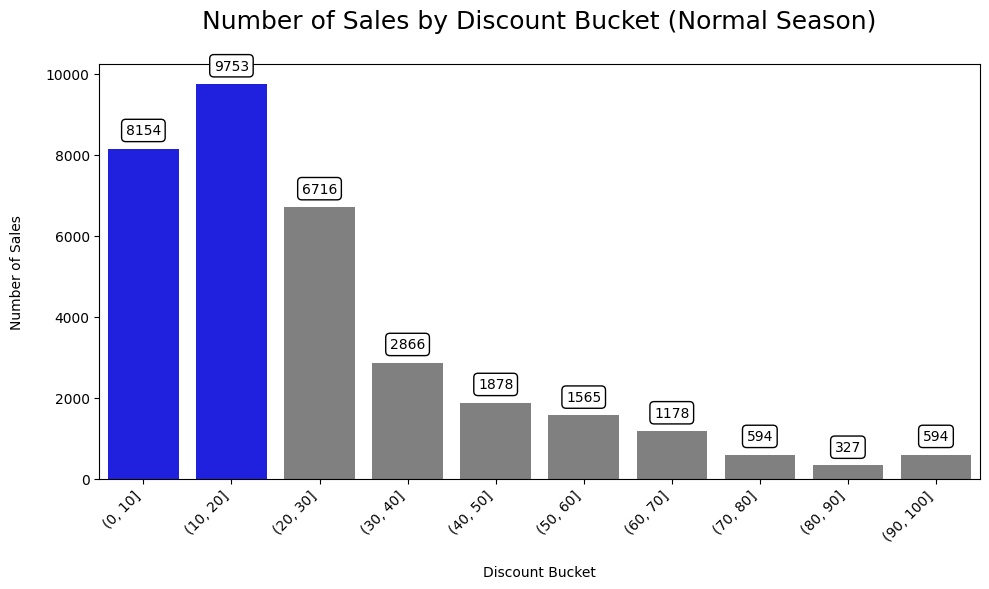

In [30]:
colors = ['blue' if sale > 8000 else 'gray' for sale in sales_bucket['sales']]
plt.figure(figsize=(10,6))

ax = sns.barplot(
    data=sales_bucket,
    x="rabatt_bucket",
    y="sales",
    hue="rabatt_bucket",
    legend=False,
    palette=colors
)

for container in ax.containers:
    ax.bar_label(
        container,
        fmt="%.0f",
        padding=8,
        bbox=dict(
            facecolor="white",
            edgecolor="black",
            boxstyle="round,pad=0.3"
        )
    )

plt.title("Number of Sales by Discount Bucket (Normal Season)\n", fontsize=18)
plt.xlabel("\nDiscount Bucket")
plt.ylabel("Number of Sales\n")
plt.xticks(rotation=45, ha='right')

plt.tight_layout()
plt.savefig('charts_03_02.png', dpi=300, bbox_inches='tight')

plt.show()
# Erkenntnis:
# Die meisten Verkäufe entfallen auf bestimmte
# Rabattkategorien.

In [31]:
files.download('charts_03_02.png')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

##Frage 6 – Durchschnittlicher Umsatz nach Rabattstufe (Peak Season)

In [32]:
# ----------------------------------------------------------
# Frage 6
# Durchschnittlicher Umsatz nach Rabattkategorie
# in der Peak Season.
# ----------------------------------------------------------
peak_df = sales_df[sales_df["season"] == "Peak Season"]

In [33]:
peak_discount = (
    peak_df
    .groupby("rabatt_bucket")["umsatz"]
    .mean()
    .round(2)
    .reset_index()
)

peak_discount

,rabatt_bucket,umsatz
0,"(0, 10]",585.09
1,"(10, 20]",288.95
2,"(20, 30]",175.22
3,"(30, 40]",78.03
4,"(40, 50]",42.22
5,"(50, 60]",30.91
6,"(60, 70]",20.36
7,"(70, 80]",23.81
8,"(80, 90]",72.51
9,"(90, 100]",588.47


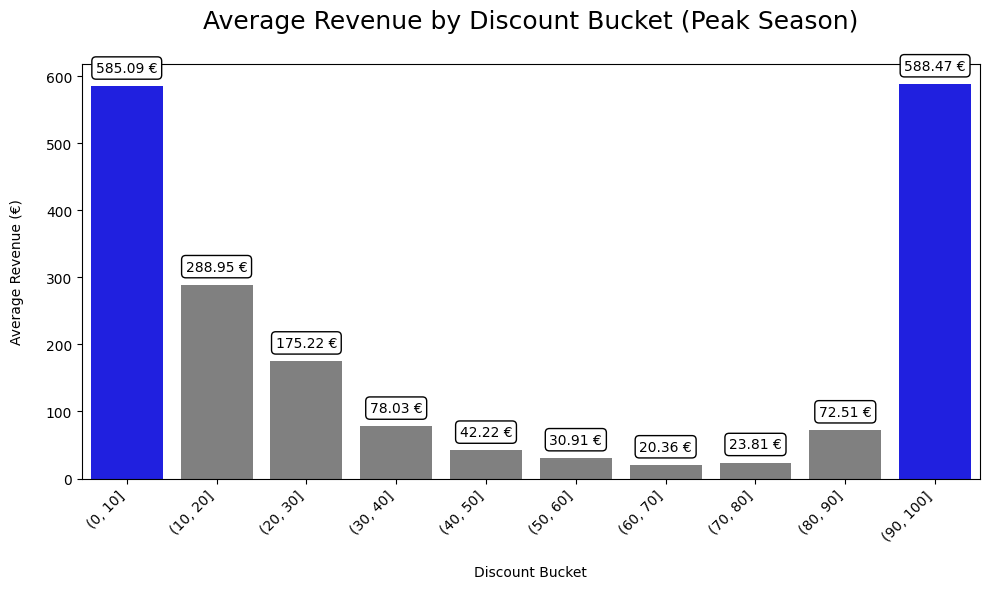

In [34]:
colors = ['blue' if umsatz > 500 else 'gray' for umsatz in peak_discount['umsatz']]
plt.figure(figsize=(10,6))

ax = sns.barplot(
    data=peak_discount,
    x="rabatt_bucket",
    y="umsatz",
    color=colors,
    hue="rabatt_bucket",
    legend=False,
    palette=colors
)

for container in ax.containers:
    ax.bar_label(
        container,
        fmt="%.2f €",
        padding=8,
        bbox=dict(
            facecolor="white",
            edgecolor="black",
            boxstyle="round,pad=0.3"
        )
    )

plt.title("Average Revenue by Discount Bucket (Peak Season)\n", fontsize=18)
plt.xlabel("\nDiscount Bucket")
plt.ylabel("Average Revenue (€)\n")
plt.xticks(rotation=45, ha='right')

plt.tight_layout()
plt.savefig('charts_04_01.png', dpi=300, bbox_inches='tight')
plt.show()
# Erkenntnis:
# Auch in der Peak Season führen kleine bis mittlere
# Rabatte zu den höchsten Umsätzen.

In [35]:
files.download('charts_04_01.png')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

##Frage 7 – Verkäufe nach Rabattstufe (Peak Season)

In [36]:
# ----------------------------------------------------------
# Frage 7
# Anzahl der Verkäufe je Rabattkategorie
# in der Peak Season.
# ----------------------------------------------------------
peak_df = sales_df[sales_df["season"] == "Peak Season"]

peak_discount = peak_df.groupby(["season", "rabatt_bucket"])["umsatz"].count().reset_index()

peak_discount

,season,rabatt_bucket,umsatz
0,Peak Season,"(0, 10]",5119
1,Peak Season,"(10, 20]",6842
2,Peak Season,"(20, 30]",5564
3,Peak Season,"(30, 40]",1886
4,Peak Season,"(40, 50]",1018
5,Peak Season,"(50, 60]",489
6,Peak Season,"(60, 70]",560
7,Peak Season,"(70, 80]",348
8,Peak Season,"(80, 90]",102
9,Peak Season,"(90, 100]",460


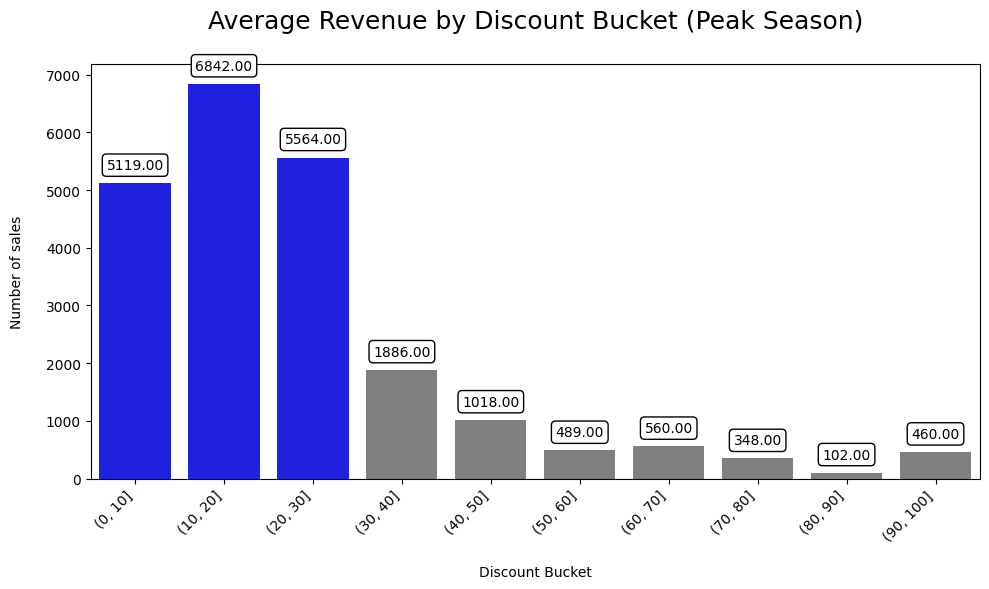

In [37]:
colors = ['blue' if umsatz > 5000 else 'gray' for umsatz in peak_discount['umsatz']]
plt.figure(figsize=(10,6))

ax = sns.barplot(
    data=peak_discount,
    x="rabatt_bucket",
    y="umsatz",
    color=colors,
    hue="rabatt_bucket",
    legend=False,
    palette=colors
)

for container in ax.containers:
    ax.bar_label(
        container,
        fmt="%.2f",
        padding=8,
        bbox=dict(
            facecolor="white",
            edgecolor="black",
            boxstyle="round,pad=0.3"
        )
    )

plt.title("Average Revenue by Discount Bucket (Peak Season)\n", fontsize=18)
plt.xlabel("\nDiscount Bucket")
plt.ylabel("Number of sales\n")
plt.xticks(rotation=45, ha='right')

plt.tight_layout()
plt.savefig('charts_04_02.png', dpi=300, bbox_inches='tight')

plt.show()
# Erkenntnis:
# Die Verkaufszahlen steigen während der Peak Season
# deutlich an.

In [38]:
files.download('charts_04_02.png')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

##Frage 8 – Top 10 Produkte

In [39]:
# ----------------------------------------------------------
# Frage 8
# Top 10 Produkte nach Gesamtumsatz
# während der Peak Season.
# ----------------------------------------------------------
peak_df = sales_df[sales_df["season"] == "Peak Season"]

top_product = (
    peak_df.groupby("name")
    .agg(
        total_revenue=("umsatz", "sum"),
        avg_discount=("discount_percent", "mean")
    )
    .sort_values("total_revenue", ascending=False)
    .head(10)
    .reset_index()
)



In [40]:
top_products = (
    peak_df.groupby("name", as_index=False)
    .agg(
        total_revenue=("umsatz","sum"),
        avg_discount=("discount_percent","mean")
    )
    .nlargest(10, "total_revenue")
)



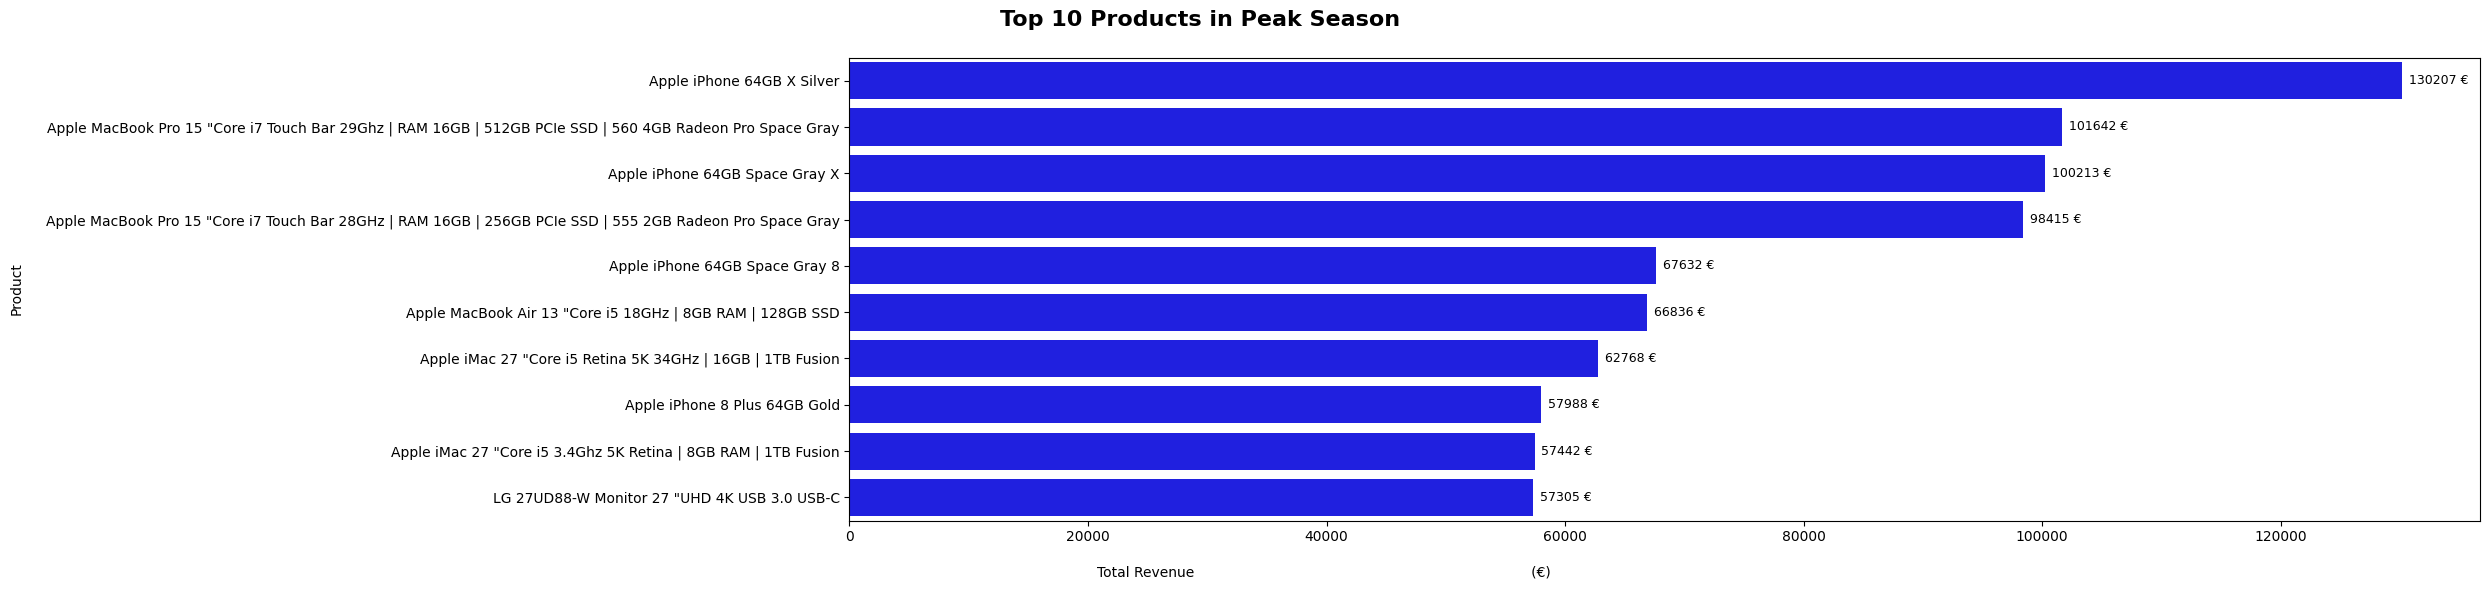

In [41]:
plt.figure(figsize=(25,6))

ax = sns.barplot(
    data=top_products,
    x="total_revenue",
    y="name",
    color='blue',
    dodge=False,
    legend=False
)

for container in ax.containers:
    ax.bar_label(
        container,
        fmt="%.0f €",
        padding=5,
        fontsize=9
    )

plt.title(
    "Top 10 Products in Peak Season                                                                                                                        \n",
    fontsize=16,
    fontweight="bold"
)

plt.xlabel("\nTotal Revenue                                                                             (€)                                                                                                                                                            ")
plt.ylabel("Product\n")

plt.tight_layout()
plt.savefig('charts_05.png', dpi=300, bbox_inches='tight')

plt.show()
# Erkenntnis:
# Die umsatzstärksten Produkte erreichen hohe Umsätze,
# ohne dass dafür die höchsten Rabatte erforderlich sind.

In [42]:
files.download('charts_05.png')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>



Wie kann die Datenerfassung verbessert werden?

Beobachtungen
Einige Datensätze enthalten fehlende oder unvollständige Informationen.
Es fehlen wichtige Merkmale wie Kundeninformationen oder Marketingkampagnen.
Saisonale Ereignisse (z. B. Black Friday oder Weihnachten) sind nicht direkt im Datensatz gekennzeichnet.
Produktkategorien könnten weiter standardisiert werden.
Empfehlungen
Einheitliche Produktkategorien verwenden.
Saison- und Kampagneninformationen direkt speichern.
Kundendaten und Marketingkanäle ergänzen.
Regelmäßige Qualitätskontrollen der Daten durchführen.
Fehlende Werte frühzeitig erkennen und vermeiden.
Fazit

Eine bessere Datenqualität ermöglicht genauere Analysen und unterstützt fundierte Geschäftsentscheidungen.

Produktklassifizierung und Verbesserung der Datenerfassung
Empfohlene Produktklassifizierung

Um Berichte und Analysen zu vereinfachen, empfehlen wir folgende Produktkategorien:

Smartphones
Laptops
Desktop-PCs
Speichergeräte
Computerkomponenten
Zubehör
Sonstige Elektronik
Vorteile
Bessere Übersicht über das Produktsortiment
Einfachere Erstellung von Berichten
Schnellere Analyse der Verkaufsleistung
Unterstützung fundierter Geschäftsentscheidungen
Verbesserung der Datenerfassung
Einheitliche Produktkategorien verwenden.
Verkaufsaktionen (z. B. Black Friday oder Weihnachten) erfassen.
Kundensegmente dokumentieren.
Produktkosten und Gewinnmargen speichern.
Fehlende oder fehlerhafte Daten regelmäßig überprüfen und bereinigen.